I use the extended version of the dataset because it includes weekly study hours, which is the main variable in this project.

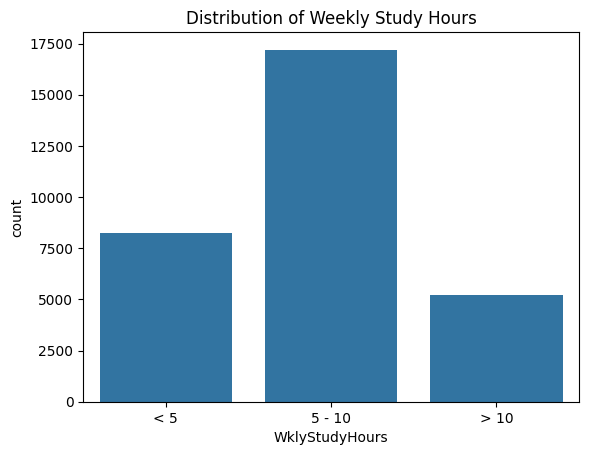

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Expanded_data_with_more_features.csv")

df = df.fillna(df.mode().iloc[0])

df['exam_score'] = (df['MathScore'] + df['ReadingScore'] + df['WritingScore']) / 3

sns.countplot(x='WklyStudyHours', data=df, order=['< 5','5 - 10','> 10'])
plt.title("Distribution of Weekly Study Hours")
plt.show()

In [5]:
df.info()
df.isnull().sum()
df = df.fillna(df.mode().iloc[0])
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          30641 non-null  object 
 3   ParentEduc           30641 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             30641 non-null  object 
 6   ParentMaritalStatus  30641 non-null  object 
 7   PracticeSport        30641 non-null  object 
 8   IsFirstChild         30641 non-null  object 
 9   NrSiblings           30641 non-null  float64
 10  TransportMeans       30641 non-null  object 
 11  WklyStudyHours       30641 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
 15  exam_score           30641 non-null 

,0
Unnamed: 0,0
Gender,0
EthnicGroup,0
ParentEduc,0
LunchType,0
TestPrep,0
ParentMaritalStatus,0
PracticeSport,0
IsFirstChild,0
NrSiblings,0


In [6]:
df["exam_score"] = (df["MathScore"] + df["ReadingScore"] + df["WritingScore"]) / 3
df[["MathScore", "ReadingScore", "WritingScore", "exam_score"]].head()
df[["MathScore", "ReadingScore", "WritingScore", "exam_score"]].describe()

,MathScore,ReadingScore,WritingScore,exam_score
count,30641.000000,30641.000000,30641.000000,30641.000000
mean,66.558402,69.377533,68.418622,68.118186
std,15.361616,14.758952,15.443525,14.454327
min,0.000000,10.000000,4.000000,9.000000
25%,56.000000,59.000000,58.000000,58.333333
50%,67.000000,70.000000,69.000000,68.333333
75%,78.000000,80.000000,79.000000,78.666667
max,100.000000,100.000000,100.000000,100.000000


I created an average exam score variable to represent overall academic performance instead of looking at three separate scores every time.

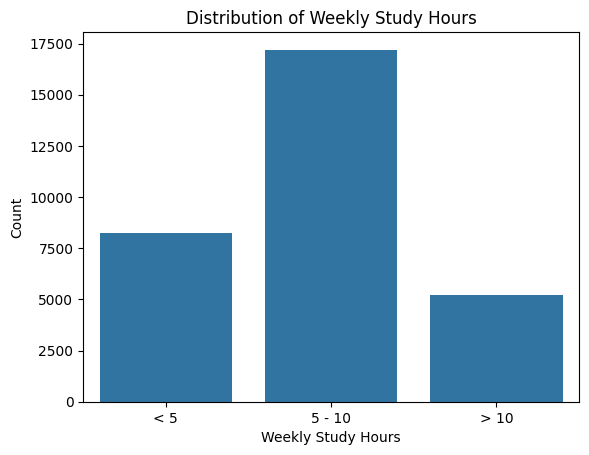

In [7]:

sns.countplot(x="WklyStudyHours", data=df, order=["< 5", "5 - 10", "> 10"])
plt.title("Distribution of Weekly Study Hours")
plt.xlabel("Weekly Study Hours")
plt.ylabel("Count")
plt.show()

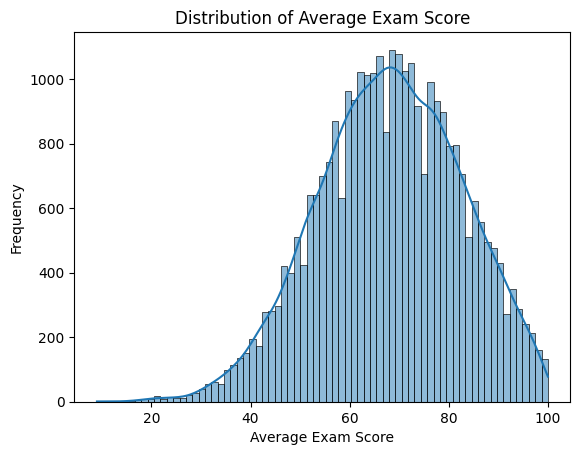

In [8]:
sns.histplot(df["exam_score"], kde=True)
plt.title("Distribution of Average Exam Score")
plt.xlabel("Average Exam Score")
plt.ylabel("Frequency")
plt.show()

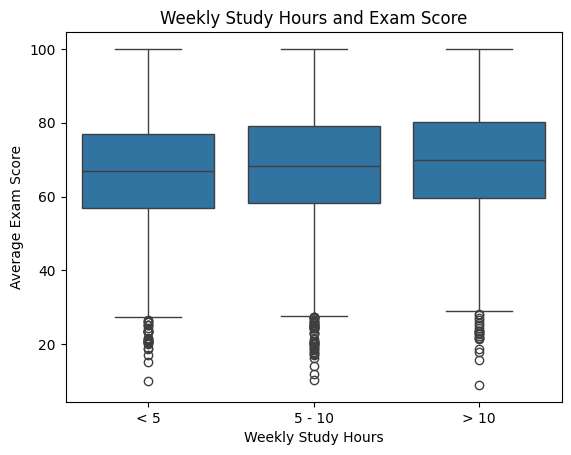

In [9]:
sns.boxplot(x="WklyStudyHours", y="exam_score", data=df, order=["< 5", "5 - 10", "> 10"])
plt.title("Weekly Study Hours and Exam Score")
plt.xlabel("Weekly Study Hours")
plt.ylabel("Average Exam Score")
plt.show()

Students in higher study-hour groups generally have higher exam scores, there is still a visible positive relationship!!!!!!!!!THIS PART IS THE MOST IMPORTANT PART FOR OUR PROJECT

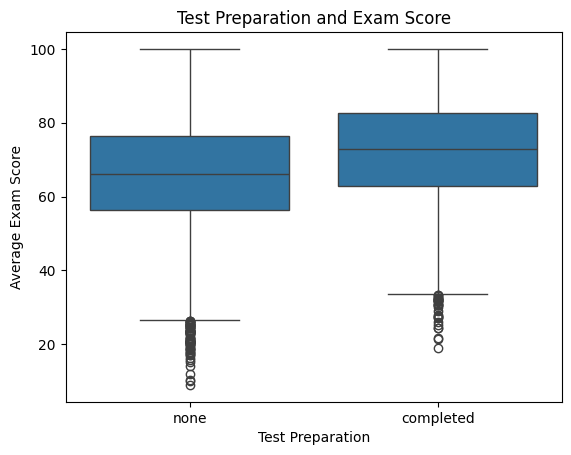

In [10]:
sns.boxplot(x="TestPrep", y="exam_score", data=df)
plt.title("Test Preparation and Exam Score")
plt.xlabel("Test Preparation")
plt.ylabel("Average Exam Score")
plt.show()

Students who completed the test preparation course seem to score higher on average. This suggests that study time may not be the only factor related to performance.This part is extra for project.

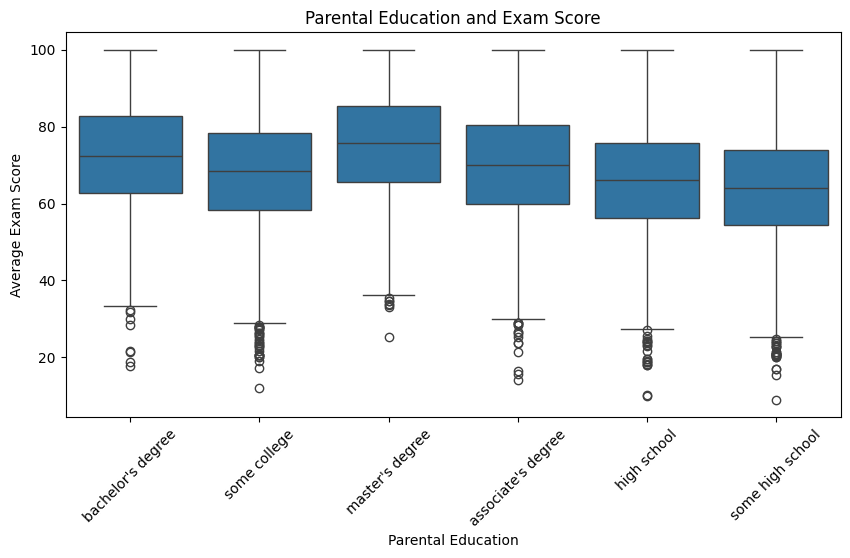

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x="ParentEduc", y="exam_score", data=df)
plt.title("Parental Education and Exam Score")
plt.xlabel("Parental Education")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=45)
plt.show()

There also seems to be some variation in exam scores across parental education levels, so background factors may also matter.This part is extra for project.

STATISTICAL TESTING

In [12]:
study_map = {"< 5": 1, "5 - 10": 2, "> 10": 3}
df["study_num"] = df["WklyStudyHours"].map(study_map)

df[["WklyStudyHours", "study_num"]].head()

,WklyStudyHours,study_num
0,< 5,1
1,5 - 10,2
2,< 5,1
3,5 - 10,2
4,5 - 10,2


Since weekly study hours are stored as categories, I converted them into ordered numeric values for statistical testing.

H0: There is no relationship between weekly study time and average exam score.

H1: There is a relationship between weekly study time and average exam score.

In [14]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(df["study_num"], df["exam_score"])
print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.06949939749068455
P-value: 3.982407150304294e-34


**Since p_value < 0.05:**
The p-value is below 0.05, so the null hypothesis is rejected. This means there is a statistically significant relationship between weekly study time and average exam score.
The correlation between study time and exam score is positive but very weak. Although the p-value is extremely small, indicating statistical significance, the strength of the relationship is quite low. This suggests that study time alone is not a strong predictor of academic performance.


Based on the analysis, there is a statistically significant relationship between weekly study time and exam scores. However, the correlation coefficient is extremely low, indicating that this relationship is very weak.
Overall, it can be observed that students who spend more time studying tend to perform slightly better in exams on average. Still, the relationship is not perfectly straightforward, and after a certain point, studying more may not lead to equally strong improvements.
It is also clear that other factors, such as test preparation, prior knowledge, and family background, play an important role in academic performance. Therefore, study time alone is not enough to fully explain student success.
In general, study time is a relevant factor, but it should be evaluated together with other variables to better understand academic outcomes.